# 09 - Improved CNN v2 (PyTorch)

This notebook trains **Improved CNN v2** on the new processed dataset:

`I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\`

## Goal
Keep the original **50-class task**, but improve generalization by adding overlap-class images from Dataset 2 into training and validation.

## Evaluations
1. Internal test on `test/`
2. External test on `external_test_dataset2_overlap/`

## Main outputs
- `improved_cnn_pytorch_best_model_v2.pth`
- `improved_cnn_pytorch_training_history_v2.csv`
- `improved_cnn_pytorch_accuracy_curve_v2.png`
- `improved_cnn_pytorch_loss_curve_v2.png`
- `improved_cnn_pytorch_summary_v2.json`
- external evaluation reports and confusion matrices


In [1]:
# Imports
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [2]:
# Optional: display Chinese labels correctly on Windows
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
# Paths
PROJECT_ROOT = Path(r"I:\DeepLearning\ChineseHerb_Identify")

DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "improved_cnn_v2_dataset"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"
EXTERNAL_TEST_DIR = DATA_ROOT / "external_test_dataset2_overlap"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
MODELS_DIR = PROJECT_ROOT / "models" / "cnn"

for p in [FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR         :", TRAIN_DIR)
print("VAL_DIR           :", VAL_DIR)
print("TEST_DIR          :", TEST_DIR)
print("EXTERNAL_TEST_DIR :", EXTERNAL_TEST_DIR)

TRAIN_DIR         : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\train
VAL_DIR           : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\val
TEST_DIR          : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\test
EXTERNAL_TEST_DIR : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\external_test_dataset2_overlap


In [5]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Hyperparameters
IMG_SIZE = 160
BATCH_SIZE = 64
EPOCHS = 45
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0   # Safer for Windows notebook
PATIENCE = 5

In [7]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [8]:
# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
external_test_dataset = datasets.ImageFolder(EXTERNAL_TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

print("Train images   :", len(train_dataset))
print("Val images     :", len(val_dataset))
print("Test images    :", len(test_dataset))
print("External images:", len(external_test_dataset))

Number of classes: 50
First 10 classes: ['乌梅', '侧柏叶', '北沙参块', '北沙参条', '半夏', '地龙', '夏枯草', '大血藤', '小茴香', '巴戟天']
Train images   : 50971
Val images     : 6384
Test images    : 6232
External images: 346


In [9]:
# Save class mapping
improved_cnn_v2_class_mapping_df = pd.DataFrame({
    "class_id": list(range(len(class_names))),
    "class_name_cn": class_names
})
improved_cnn_v2_class_mapping_path = REPORTS_DIR / "improved_cnn_pytorch_class_mapping_v2.csv"
improved_cnn_v2_class_mapping_df.to_csv(improved_cnn_v2_class_mapping_path, index=False, encoding="utf-8-sig")
print("Saved:", improved_cnn_v2_class_mapping_path)
display(improved_cnn_v2_class_mapping_df.head())

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_class_mapping_v2.csv


,class_id,class_name_cn
0,0,乌梅
1,1,侧柏叶
2,2,北沙参块
3,3,北沙参条
4,4,半夏


In [10]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

external_test_loader = DataLoader(
    external_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches   :", len(train_loader))
print("Val batches     :", len(val_loader))
print("Test batches    :", len(test_loader))
print("External batches:", len(external_test_loader))

Train batches   : 797
Val batches     : 100
Test batches    : 98
External batches: 6


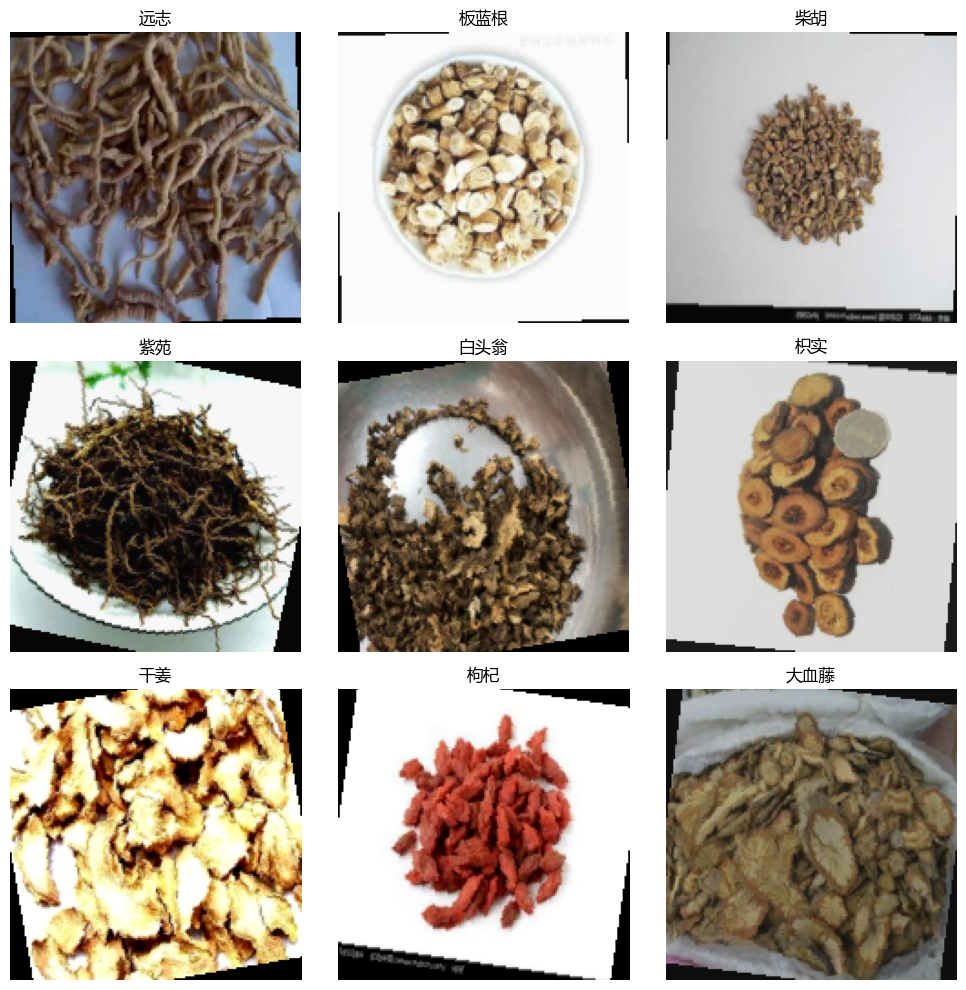

In [11]:
# Visualize a few training images
display_images, display_labels = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = display_images[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip((img * std) + mean, 0, 1)
    plt.imshow(img)
    plt.title(class_names[display_labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# Improved CNN blocks
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        return self.block(x)


class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout_rate=0.10),
            ConvBlock(32, 64, dropout_rate=0.15),
            ConvBlock(64, 128, dropout_rate=0.20),
            ConvBlock(128, 256, dropout_rate=0.25),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


improved_cnn_v2_model = ImprovedCNN(num_classes=num_classes).to(device)
improved_cnn_v2_model

ImprovedCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps

In [13]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    improved_cnn_v2_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [14]:
# Training and validation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [15]:
# Train loop
improved_cnn_v2_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

improved_cnn_v2_best_val_acc = 0.0
improved_cnn_v2_best_model_wts = copy.deepcopy(improved_cnn_v2_model.state_dict())
improved_cnn_v2_best_model_path = MODELS_DIR / "improved_cnn_pytorch_best_model_v2.pth"

patience_counter = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        improved_cnn_v2_model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, _, _ = evaluate(
        improved_cnn_v2_model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    improved_cnn_v2_history["train_loss"].append(train_loss)
    improved_cnn_v2_history["train_acc"].append(train_acc)
    improved_cnn_v2_history["val_loss"].append(val_loss)
    improved_cnn_v2_history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if val_acc > improved_cnn_v2_best_val_acc:
        improved_cnn_v2_best_val_acc = val_acc
        improved_cnn_v2_best_model_wts = copy.deepcopy(improved_cnn_v2_model.state_dict())
        torch.save(improved_cnn_v2_best_model_wts, improved_cnn_v2_best_model_path)
        patience_counter = 0
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 60)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", improved_cnn_v2_best_val_acc)
print("Best model saved to:", improved_cnn_v2_best_model_path)

Epoch 1/45


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 3.0888 | Train Acc: 0.2165
Val   Loss: 3.0798 | Val   Acc: 0.2218
Learning Rate: 0.001000
Best model updated.
------------------------------------------------------------
Epoch 2/45


  0%|          | 0/797 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 0.9494 | Train Acc: 0.9597
Val   Loss: 0.9051 | Val   Acc: 0.9635
Learning Rate: 0.000250
No improvement. Patience: 4/5
------------------------------------------------------------
Epoch 39/45


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 0.9445 | Train Acc: 0.9617
Val   Loss: 0.9168 | Val   Acc: 0.9637
Learning Rate: 0.000125
No improvement. Patience: 5/5
------------------------------------------------------------
Early stopping triggered.
Best validation accuracy: 0.9667919799498746
Best model saved to: I:\DeepLearning\ChineseHerb_Identify\models\cnn\improved_cnn_pytorch_best_model_v2.pth


In [16]:
# Save training history
improved_cnn_v2_history_df = pd.DataFrame(improved_cnn_v2_history)
improved_cnn_v2_history_path = REPORTS_DIR / "improved_cnn_pytorch_training_history_v2.csv"
improved_cnn_v2_history_df.to_csv(improved_cnn_v2_history_path, index=False)

print("Saved:", improved_cnn_v2_history_path)
display(improved_cnn_v2_history_df.head())

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_training_history_v2.csv


,train_loss,train_acc,val_loss,val_acc
0,3.088800,0.216515,3.079779,0.221805
1,2.640947,0.343764,3.281038,0.232143
2,2.335390,0.451119,2.205439,0.499687
3,2.079206,0.544231,2.183502,0.521617
4,1.902174,0.612250,1.846257,0.614818


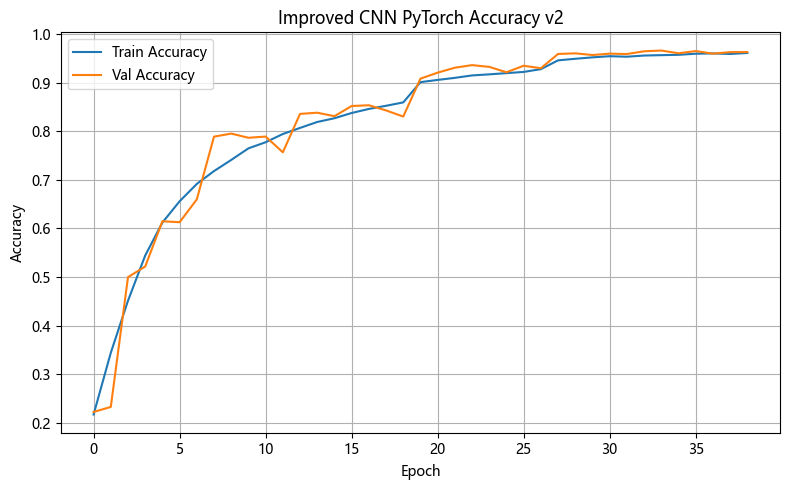

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_accuracy_curve_v2.png


In [17]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(improved_cnn_v2_history["train_acc"], label="Train Accuracy")
plt.plot(improved_cnn_v2_history["val_acc"], label="Val Accuracy")
plt.title("Improved CNN PyTorch Accuracy v2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

improved_cnn_v2_accuracy_curve_path = FIGURES_DIR / "improved_cnn_pytorch_accuracy_curve_v2.png"
plt.savefig(improved_cnn_v2_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_v2_accuracy_curve_path)

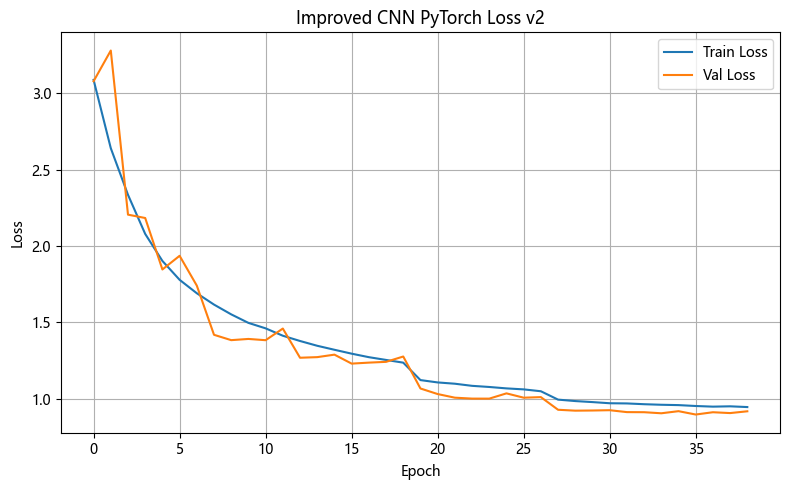

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_loss_curve_v2.png


In [18]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(improved_cnn_v2_history["train_loss"], label="Train Loss")
plt.plot(improved_cnn_v2_history["val_loss"], label="Val Loss")
plt.title("Improved CNN PyTorch Loss v2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

improved_cnn_v2_loss_curve_path = FIGURES_DIR / "improved_cnn_pytorch_loss_curve_v2.png"
plt.savefig(improved_cnn_v2_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_v2_loss_curve_path)

In [19]:
# Load best weights before testing
improved_cnn_v2_model.load_state_dict(torch.load(improved_cnn_v2_best_model_path, map_location=device))
improved_cnn_v2_model.to(device)

ImprovedCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps

In [20]:
# Internal test evaluation
improved_cnn_v2_test_loss, improved_cnn_v2_test_acc, improved_cnn_v2_y_true, improved_cnn_v2_y_pred = evaluate(
    improved_cnn_v2_model, test_loader, criterion, device
)

print(f"Improved CNN v2 Test Loss: {improved_cnn_v2_test_loss:.4f}")
print(f"Improved CNN v2 Test Accuracy: {improved_cnn_v2_test_acc:.4f}")

  0%|          | 0/98 [00:00<?, ?it/s]

Improved CNN v2 Test Loss: 0.8839
Improved CNN v2 Test Accuracy: 0.9710


In [21]:
# Internal test classification report
improved_cnn_v2_report_dict = classification_report(
    improved_cnn_v2_y_true,
    improved_cnn_v2_y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

improved_cnn_v2_report_df = pd.DataFrame(improved_cnn_v2_report_dict).transpose()
improved_cnn_v2_report_path = REPORTS_DIR / "improved_cnn_pytorch_classification_report_v2.csv"
improved_cnn_v2_report_df.to_csv(improved_cnn_v2_report_path, encoding="utf-8-sig")

print("Saved:", improved_cnn_v2_report_path)
display(improved_cnn_v2_report_df.head(10))

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_classification_report_v2.csv


,precision,recall,f1-score,support
乌梅,1.000000,0.967213,0.983333,122.0
侧柏叶,0.948276,0.982143,0.964912,112.0
北沙参块,0.991525,0.959016,0.975000,122.0
北沙参条,0.924370,1.000000,0.960699,110.0
半夏,0.982301,0.956897,0.969432,116.0
地龙,0.984733,0.984733,0.984733,131.0
夏枯草,0.972973,0.981818,0.977376,110.0
大血藤,1.000000,0.992424,0.996198,132.0
小茴香,0.925926,0.961538,0.943396,130.0
巴戟天,0.985507,0.978417,0.981949,139.0


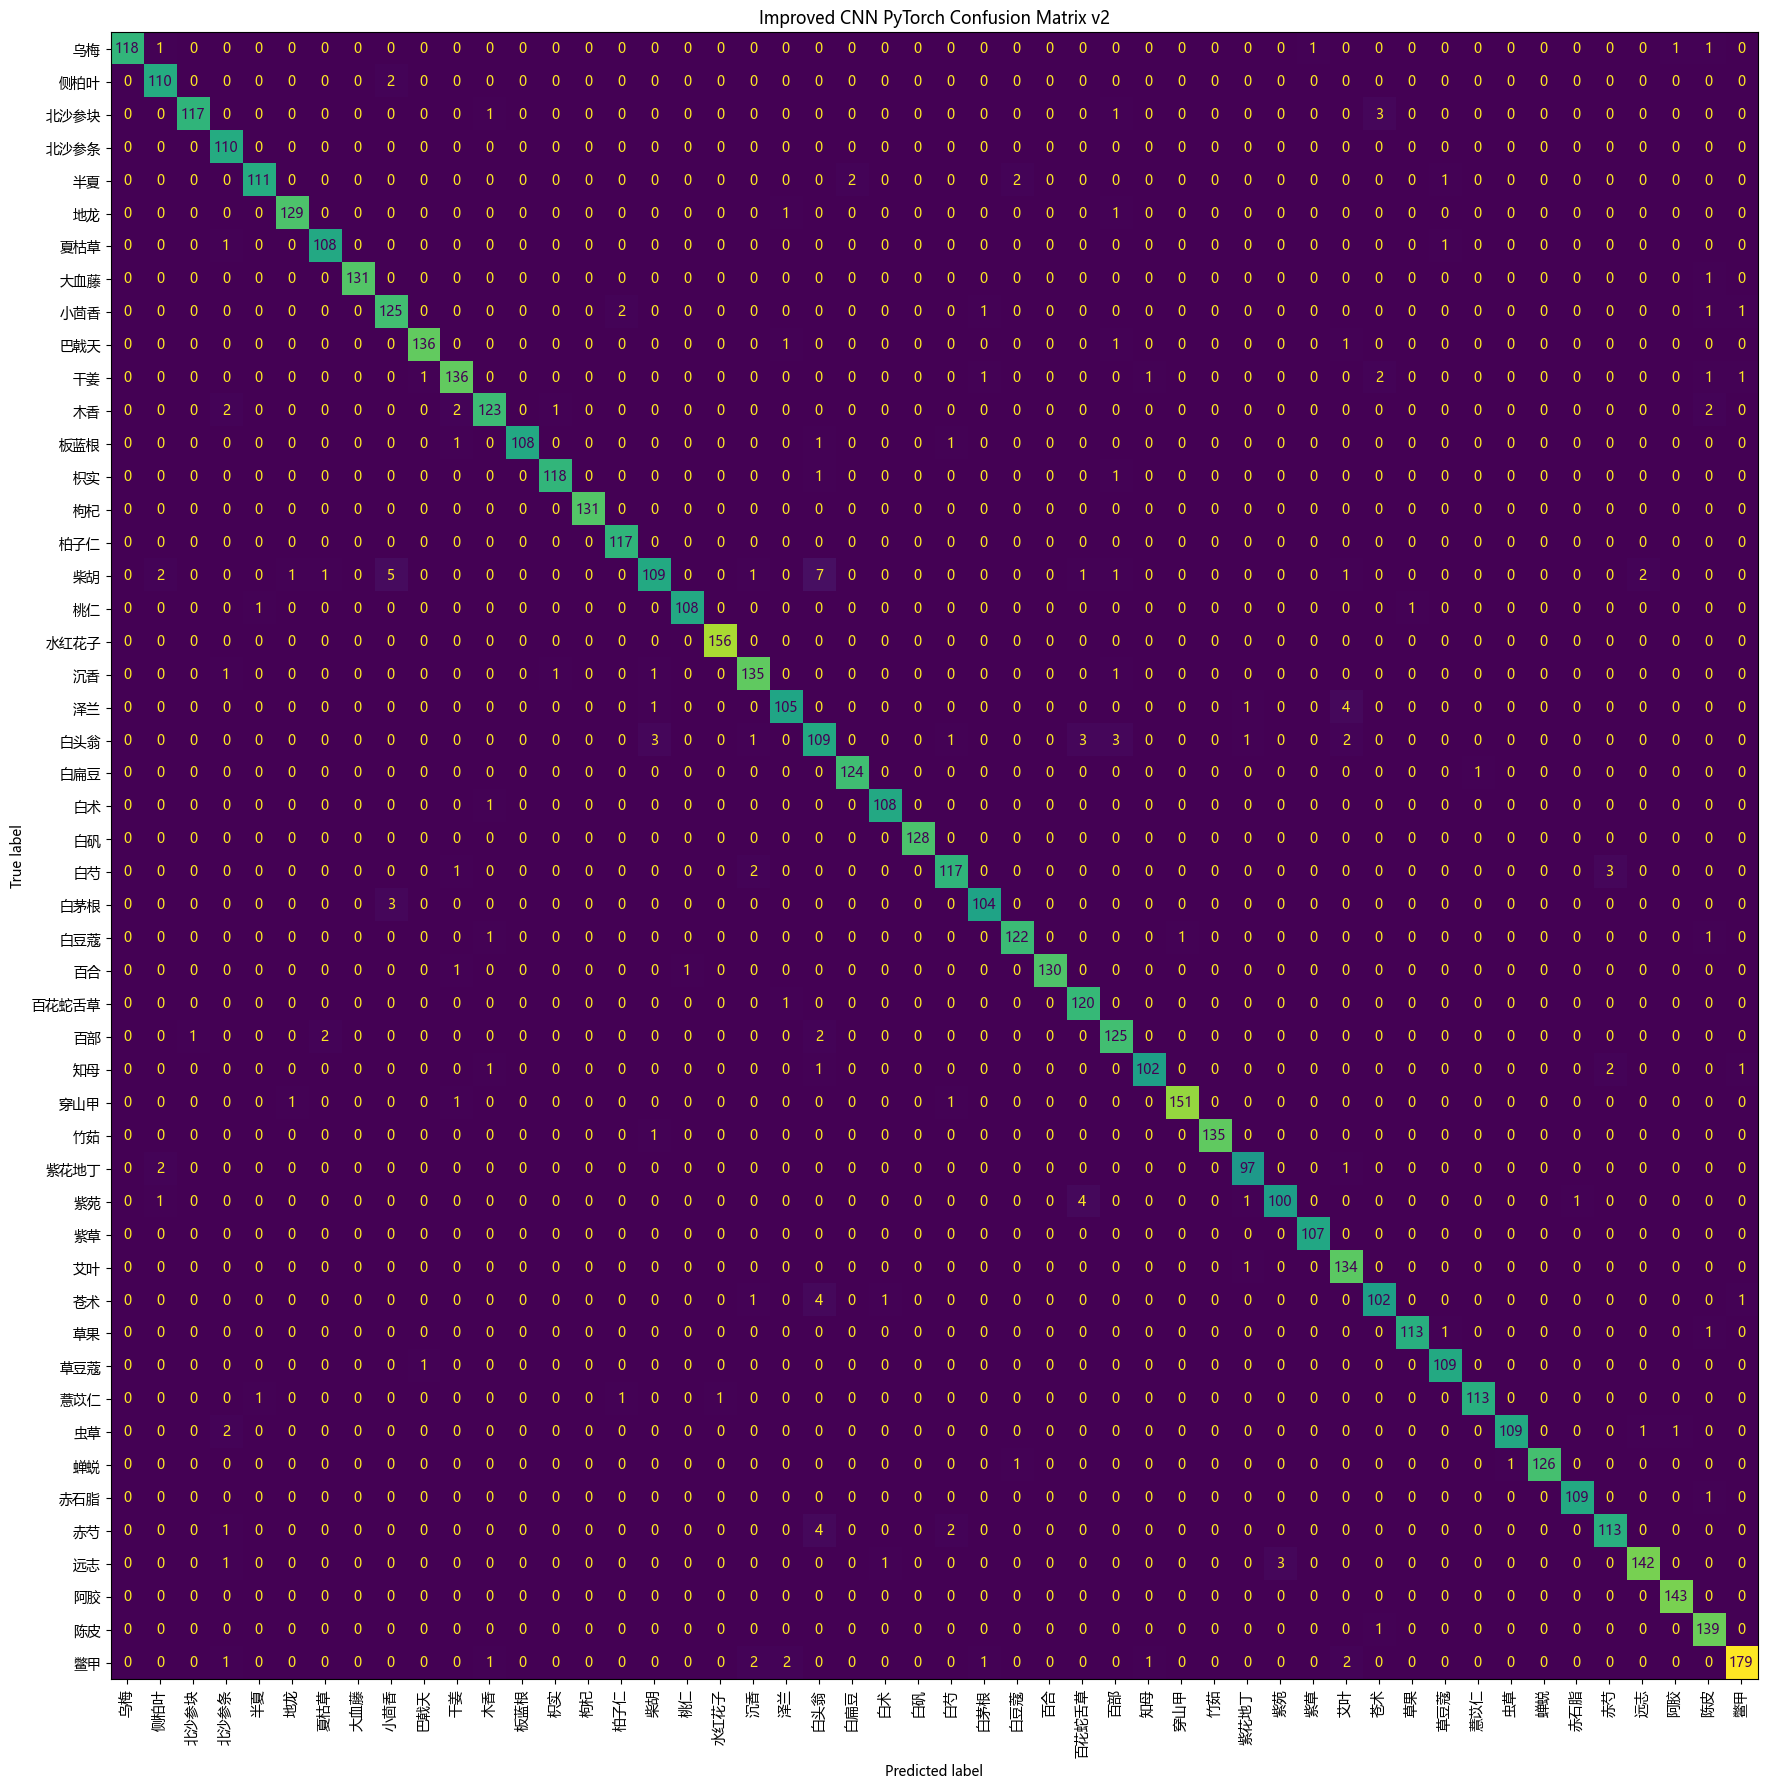

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_confusion_matrix_v2.png


In [22]:
# Internal test confusion matrix
improved_cnn_v2_cm = confusion_matrix(improved_cnn_v2_y_true, improved_cnn_v2_y_pred)

fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cnn_v2_cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Improved CNN PyTorch Confusion Matrix v2")
plt.tight_layout()

improved_cnn_v2_cm_path = FIGURES_DIR / "improved_cnn_pytorch_confusion_matrix_v2.png"
plt.savefig(improved_cnn_v2_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_v2_cm_path)

In [23]:
# External test evaluation
external_class_names = external_test_dataset.classes
external_class_to_idx = external_test_dataset.class_to_idx

improved_cnn_v2_external_loss, improved_cnn_v2_external_acc, improved_cnn_v2_external_y_true, improved_cnn_v2_external_y_pred = evaluate(
    improved_cnn_v2_model, external_test_loader, criterion, device
)

print(f"Improved CNN v2 External Loss: {improved_cnn_v2_external_loss:.4f}")
print(f"Improved CNN v2 External Accuracy: {improved_cnn_v2_external_acc:.4f}")

  0%|          | 0/6 [00:00<?, ?it/s]

Improved CNN v2 External Loss: 7.1074
Improved CNN v2 External Accuracy: 0.0029


In [24]:
# External test report only on external overlap classes
improved_cnn_v2_external_report_dict = classification_report(
    improved_cnn_v2_external_y_true,
    improved_cnn_v2_external_y_pred,
    labels=list(range(len(external_class_names))),
    target_names=external_class_names,
    output_dict=True,
    zero_division=0
)

improved_cnn_v2_external_report_df = pd.DataFrame(improved_cnn_v2_external_report_dict).transpose()
improved_cnn_v2_external_report_path = REPORTS_DIR / "improved_cnn_pytorch_external_classification_report_v2.csv"
improved_cnn_v2_external_report_df.to_csv(improved_cnn_v2_external_report_path, encoding="utf-8-sig")

print("Saved:", improved_cnn_v2_external_report_path)
display(improved_cnn_v2_external_report_df.head(20))

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_external_classification_report_v2.csv


,precision,recall,f1-score,support
夏枯草,0.000000,0.000000,0.000000,18.0
巴戟天,0.000000,0.000000,0.000000,19.0
枸杞,0.000000,0.000000,0.000000,19.0
桃仁,0.000000,0.000000,0.000000,35.0
白头翁,0.000000,0.000000,0.000000,22.0
白扁豆,0.000000,0.000000,0.000000,26.0
白术,0.000000,0.000000,0.000000,26.0
白芍,0.000000,0.000000,0.000000,25.0
白茅根,1.000000,0.030303,0.058824,33.0
百合,0.000000,0.000000,0.000000,21.0


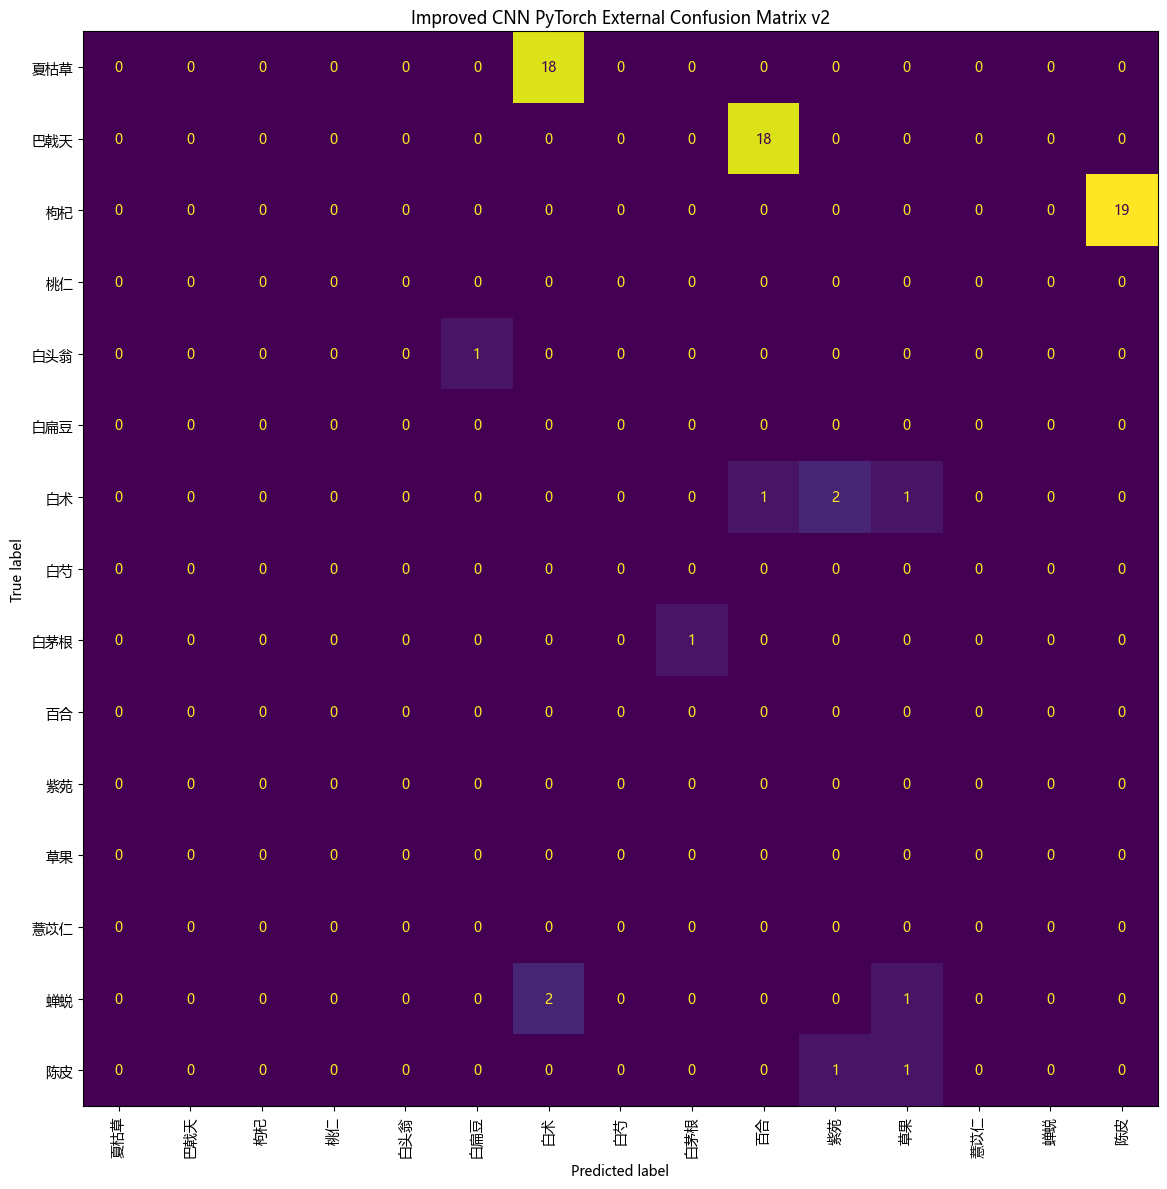

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\improved_cnn_pytorch_external_confusion_matrix_v2.png


In [25]:
# External test confusion matrix
improved_cnn_v2_external_cm = confusion_matrix(
    improved_cnn_v2_external_y_true,
    improved_cnn_v2_external_y_pred,
    labels=list(range(len(external_class_names)))
)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cnn_v2_external_cm,
    display_labels=external_class_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Improved CNN PyTorch External Confusion Matrix v2")
plt.tight_layout()

improved_cnn_v2_external_cm_path = FIGURES_DIR / "improved_cnn_pytorch_external_confusion_matrix_v2.png"
plt.savefig(improved_cnn_v2_external_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_v2_external_cm_path)

In [26]:
# Save summary
improved_cnn_v2_summary = {
    "model_name": "improved_cnn_pytorch_v2",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(improved_cnn_v2_history["train_loss"]),
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "num_classes": num_classes,
    "best_val_accuracy": float(max(improved_cnn_v2_history["val_acc"])),
    "best_val_loss": float(min(improved_cnn_v2_history["val_loss"])),
    "internal_test_loss": float(improved_cnn_v2_test_loss),
    "internal_test_accuracy": float(improved_cnn_v2_test_acc),
    "external_test_loss": float(improved_cnn_v2_external_loss),
    "external_test_accuracy": float(improved_cnn_v2_external_acc),
    "device": str(device)
}

improved_cnn_v2_summary_path = REPORTS_DIR / "improved_cnn_pytorch_summary_v2.json"
with open(improved_cnn_v2_summary_path, "w", encoding="utf-8") as f:
    json.dump(improved_cnn_v2_summary, f, ensure_ascii=False, indent=4)

print("Saved:", improved_cnn_v2_summary_path)
improved_cnn_v2_summary

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\improved_cnn_pytorch_summary_v2.json


{'model_name': 'improved_cnn_pytorch_v2',
 'image_size': 160,
 'batch_size': 64,
 'epochs_requested': 45,
 'epochs_completed': 39,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'num_classes': 50,
 'best_val_accuracy': 0.9667919799498746,
 'best_val_loss': 0.8956208722035688,
 'internal_test_loss': 0.883943500353528,
 'internal_test_accuracy': 0.9709563543003851,
 'external_test_loss': 7.107390403747559,
 'external_test_accuracy': 0.002890173410404624,
 'device': 'cuda'}